# Political Fairness Audit

Extension of the *Moral Frame Preserving News Summarization* paper (Bondielli et al., COLM 2025) into a political-fairness analysis.

**Goal:** check whether the paper's prompting methods (Plain / Direct / CoT / Oracle / Class) preserve moral framing *equally* across left-, center-, and right-leaning news articles, and whether the gap depends on the prompting strategy.

**Data:** the AllSides subset of EMONA, where every article filename encodes its political leaning (`allsides_<topic>_<l|c|r>_<n>`). The paper ran three models (Llama-3-70B, CommandR-Plus, DeepSeek-R1-Distill-Qwen-32B) on **180 AllSides articles each** (60 left / 60 center / 60 right, across 12 topics).

This notebook focuses on Llama-3-70B for the deep dive; cross-model comparison is a follow-up.

All data is loaded into in-memory DataFrames -- no CSV side-effects.

## 0. Imports
All required libraries.

In [57]:
import sys
from pathlib import Path
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Load the data

`data_loader.py` lives in the repo root. It pulls the three precomputed metric pickles in `results/automated_evaluation/`, normalizes the `QaFactEval`/`QAFactEval` key inconsistency, drops the `mean`/`std` summary rows, deduplicates rows that appear in more than one pickle (preferring the larger-coverage source), and parses topic/leaning out of the AllSides article IDs.

In [58]:
# Make sure we can import data_loader.py from the repo root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data_loader import (
    build_full_long,
    build_wide_by_method,
    allsides_only,
    summary_counts,
    PROMPTING_METHODS,
    PAPER_NAME_MAP,
)

# Set global options for Pandas and Seaborn
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


In [59]:
# Build the master long-format and wide-format DataFrames once.
long_df = build_full_long()
wide_df = build_wide_by_method(long_df)

print(f"long_df: {len(long_df):,} rows  -- one row per (model, article, prompting_method, metric)")
print(f"wide_df: {len(wide_df):,} rows  -- one row per (model, article, metric); prompting methods are columns")

long_df: 38,400 rows  -- one row per (model, article, prompting_method, metric)
wide_df: 7,165 rows  -- one row per (model, article, metric); prompting methods are columns


## 2. Sanity check: counts per leaning

We expect **180 AllSides articles per model**, balanced 60 left / 60 center / 60 right.

In [60]:
summary_counts(long_df)

leaning,model,center,left,right
0,DeepSeek-R1-Distill-Qwen-32B,60,60,60
1,Meta-Llama-3-70B-Instruct,60,60,60
2,c4ai-command-r-plus-4bit,60,60,60


### Topic x leaning breakdown

EMONA-AllSides is a fully balanced factorial: 12 topics x 3 leanings x 5 replicate articles.

In [61]:
topic_breakdown = (
    allsides_only(long_df)
    .query("model == 'Meta-Llama-3-70B-Instruct' and metric == 'moral_count' and prompting_method == 'vanilla'")
    .groupby(["topic", "leaning"]).size()
    .unstack("leaning", fill_value=0)
)
topic_breakdown

leaning,center,left,right
topic,,,
abortion,5,5,5
coronavirus,5,5,5
elections,5,5,5
gun_control_and_gun_rights,5,5,5
immigration,5,5,5
lgbt_rights,5,5,5
politics,5,5,5
race_and_racism,5,5,5
us_house,5,5,5


## 3. First peek: mean moral_count by leaning x method (Llama)

Raw moral-word retention by political leaning. This is **not** the retention rate yet -- it's the absolute count of moral words preserved in the summary. Left-leaning articles may simply contain more moral language to begin with, which would show up as a higher absolute count even under fair preservation.

We'll convert to a proper retention rate (`moral_count / original`) in the next notebook.

In [62]:
llama_moral_count = (
    allsides_only(long_df)
    .query("model == 'Meta-Llama-3-70B-Instruct' and metric == 'moral_count'")
    .query("prompting_method in @PROMPTING_METHODS")
)

peek = (
    llama_moral_count
    .groupby(["leaning", "prompting_method"])["value"]
    .mean()
    .unstack("prompting_method")
    .round(2)
    # Reorder columns into the paper's naming order: Plain, Direct, CoT, Oracle, Class
    [PROMPTING_METHODS]
    .rename(columns=PAPER_NAME_MAP)
)
peek

prompting_method,Plain,Direct,CoT,Oracle,Class
leaning,,,,,
center,6.48,6.99,7.92,10.86,10.04
left,7.85,8.40,9.19,12.86,11.13
right,7.54,8.27,9.07,12.14,8.67


Also handy: the per-article original (source) moral-word count, by leaning. This tells us whether left/center/right articles differ in baseline moral density.

In [63]:
original_moral_density = (
    allsides_only(long_df)
    .query("model == 'Meta-Llama-3-70B-Instruct' and metric == 'moral_count' and prompting_method == 'original'")
    .groupby("leaning")["value"]
    .agg(["mean", "std", "count"])
    .round(2)
)
original_moral_density

,mean,std,count
leaning,,,
center,21.53,10.63,60
left,27.82,12.99,60
right,23.72,12.80,60


## 4. Statistical Analysis Preprocessing
Here we pivot the metrics so `moral_count` and `moral_div` are columns, and filter out any datasets missing political leaning (like MPQA).

In [64]:
# Pivot the metrics into columns (long_df was already built above!)
df_pivoted = long_df.pivot_table(
    index=['model', 'dataset', 'article', 'leaning', 'prompting_method'],
    columns='metric',
    values='value',
    aggfunc='first'
).reset_index()

df = df_pivoted

# Drop rows where leaning is missing (e.g., MPQA dataset)
df = df.dropna(subset=['leaning'])

# Drop 'original' prompting_method since it represents the baseline article
df_summaries = df[df['prompting_method'] != 'original']
df_summaries.head()

metric,model,dataset,article,leaning,prompting_method,BLANC,QAFactEval,length,moral_count,moral_div,summaC
0,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_1,center,cot,0.14,2.81,152.0,3.5,0.37,0.34
1,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_1,center,oracle,0.14,3.00,156.0,11.6,0.10,0.32
3,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_1,center,simple,0.17,3.23,181.8,6.0,0.26,0.35
4,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_1,center,vanilla,0.15,3.12,171.2,4.4,0.33,0.40
5,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_2,center,class,0.12,3.25,187.2,13.0,0.20,0.30


## 5. Descriptive Statistics
Let's look at the basic averages (mean) and standard deviations (std) for moral preservation across each strategy and ideology.

In [65]:
stats_summary = df_summaries.groupby(['prompting_method', 'leaning'])[['moral_count', 'moral_div']].agg(['mean', 'std', 'count']).round(3)
display(stats_summary)

metric                   moral_count              moral_div             
                                mean    std count      mean    std count
prompting_method leaning                                                
class            center        9.915  5.128    33     0.233  0.133    32
                 left         10.978  2.641    27     0.182  0.051    27
                 right         8.230  2.408    27     0.201  0.088    27
cot              center        7.728  3.532   180     0.239  0.111   177
                 left          9.116  3.679   180     0.220  0.079   176
                 right         8.744  3.767   180     0.208  0.079   177
oracle           center       10.698  4.114   180     0.181  0.088   180
                 left         12.496  4.489   180     0.178  0.068   180
                 right        11.720  4.402   180     0.161  0.065   180
simple           center        6.728  3.389   180     0.255  0.116   169
                 left          7.910  3.202   180     0.241  0.076   177
                 right         7.518  3.568   180     0.231  0.087   178
vanilla          center        6.199  3.191   180     0.272  0.120   169
                 left          7.391  2.970   180     0.244  0.083   176
                 right         6.823  3.347   180     0.239  0.096   176

## 6. Kruskal-Wallis & Mann-Whitney U Tests (Moral Count)
**Goal:** Check if the AI model treats Left, Center, and Right articles differently when preserving moral words.
- **Kruskal-Wallis:** Tells us if there is *any* difference across the 3 groups.
- **Mann-Whitney U:** If a difference exists, this tells us *which* specific groups (e.g. Left vs Right) are different.

In [66]:
print("Non-Parametric Tests for: moral_count")

# Separate the data by leaning
left = df_summaries[df_summaries['leaning'] == 'left']['moral_count'].dropna()
center = df_summaries[df_summaries['leaning'] == 'center']['moral_count'].dropna()
right = df_summaries[df_summaries['leaning'] == 'right']['moral_count'].dropna()

# 1. Kruskal-Wallis H-test
h_stat, p_val = stats.kruskal(left, center, right)
print(f"Kruskal-Wallis H-statistic: {h_stat:.3f}, p-value: {p_val:.3e}")

if p_val < 0.05:
    print("\n-> Significant difference found across ideologies! Proceeding with Mann-Whitney U pairwise tests:\n")
    
    # 2. Mann-Whitney U tests
    u_stat_lc, p_val_lc = stats.mannwhitneyu(left, center, alternative='two-sided')
    print(f"   Left vs Center: U-statistic = {u_stat_lc:.1f}, p-value = {p_val_lc:.3e}")
    
    u_stat_cr, p_val_cr = stats.mannwhitneyu(center, right, alternative='two-sided')
    print(f"   Center vs Right: U-statistic = {u_stat_cr:.1f}, p-value = {p_val_cr:.3e}")
    
    u_stat_lr, p_val_lr = stats.mannwhitneyu(left, right, alternative='two-sided')
    print(f"   Left vs Right: U-statistic = {u_stat_lr:.1f}, p-value = {p_val_lr:.3e}")
else:
    print("\n-> No significant difference found across ideologies.")

Non-Parametric Tests for: moral_count
Kruskal-Wallis H-statistic: 38.162, p-value: 5.167e-09

-> Significant difference found across ideologies! Proceeding with Mann-Whitney U pairwise tests:

   Left vs Center: U-statistic = 333007.5, p-value = 6.759e-10
   Center vs Right: U-statistic = 254466.5, p-value = 1.409e-03
   Left vs Right: U-statistic = 303883.0, p-value = 2.844e-03


## 7. [PLACEHOLDER] Few-Shot vs 0-Shot
**Goal:** This is a dedicated skeleton for the new dynamic few-shot method currently running on the supercomputer. Once the new data is available, change the `dynamic_strategy_name` below to match whatever your teammate names it in the `.pickle` file.

In [67]:
print("Wilcoxon Signed-Rank Test for Few-Shot Method")

# TODO: Change this placeholder to match the actual name your teammate uses in the new pickle file!
dynamic_strategy_name = 'few_shot_PLACEHOLDER'  
baseline_strategy = 'vanilla'

dynamic_data = df_summaries[df_summaries['prompting_method'] == dynamic_strategy_name].set_index(['model', 'dataset', 'article'])
baseline_data = df_summaries[df_summaries['prompting_method'] == baseline_strategy].set_index(['model', 'dataset', 'article'])

if dynamic_data.empty:
    print(f"WARNING: Could not find the method '{dynamic_strategy_name}' in the data! Make sure you loaded the new pickle file.")
else:
    common_indices = baseline_data.index.intersection(dynamic_data.index)
    
    if len(common_indices) > 0:
        aligned_data = pd.concat([
            dynamic_data.loc[common_indices, 'moral_count'], 
            baseline_data.loc[common_indices, 'moral_count']
        ], axis=1).dropna()
        
        if len(aligned_data) > 0:
            import scipy.stats as stats
            stat, p_val = stats.wilcoxon(aligned_data.iloc[:, 0], aligned_data.iloc[:, 1])
            print(f"{dynamic_strategy_name} vs {baseline_strategy} ({len(aligned_data)} paired samples)")
            print(f"W-statistic: {stat:.1f}, p-value: {p_val:.3e}")
            
            if p_val < 0.05:
                 print(f"\n-> Significant difference! The Few-Shot method performs differently than 0-Shot.\n")
            else:
                 print(f"\n-> No significant difference.\n")
        else:
            print("Not enough paired data without NaNs to compare.")
    else:
        print("No overlapping articles found between the Few-Shot method and the baseline.")


Wilcoxon Signed-Rank Test for Few-Shot Method


## 8. Visualizations
These figures are designed specifically to demonstrate political bias (or fairness).

### 8.1. Trend Analysis (Pointplot)
This plot clearly shows if the average moral count shifts across ideologies. 

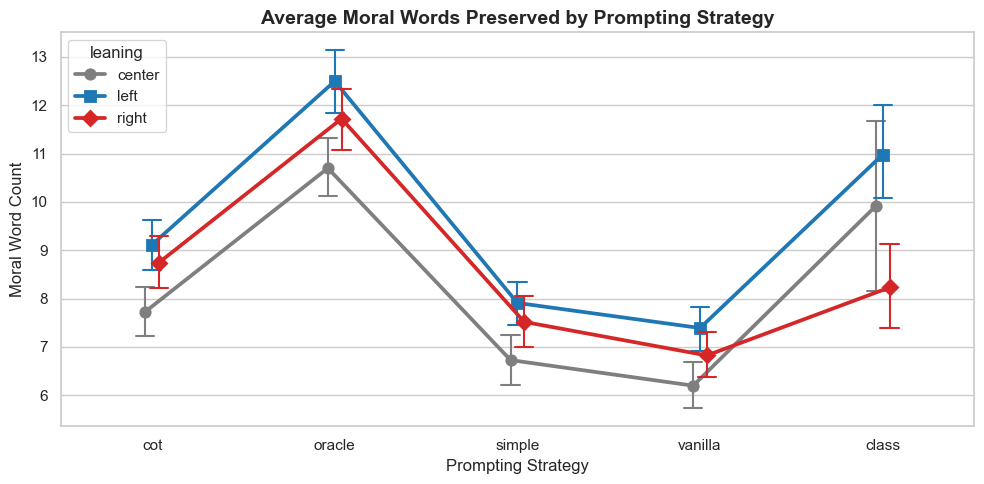

In [68]:
sns.set_theme(style="whitegrid", palette="muted")
ideology_colors = {'left': '#1f77b4', 'center': '#7f7f7f', 'right': '#d62728'}

if 'moral_count' in df_summaries.columns:
    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=df_summaries, 
        x='prompting_method', 
        y='moral_count', 
        hue='leaning', 
        palette=ideology_colors,
        dodge=True, 
        markers=['o', 's', 'D'],
        capsize=.1,
        err_kws={'linewidth': 1.5}
    )
    plt.title('Average Moral Words Preserved by Prompting Strategy', fontsize=14, fontweight='bold')
    plt.xlabel('Prompting Strategy', fontsize=12)
    plt.ylabel('Moral Word Count', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig1_moral_count_trend.png', dpi=300)
    plt.show()

### 8.2. Moral Retention Rate (% of Original)
This calculates exactly what percentage of the *original* article's moral words were preserved by the AI (e.g. 1.0 = kept 100%). If the AI is fair, all three bars should be perfectly level. This is the most crucial metric for proving bias!

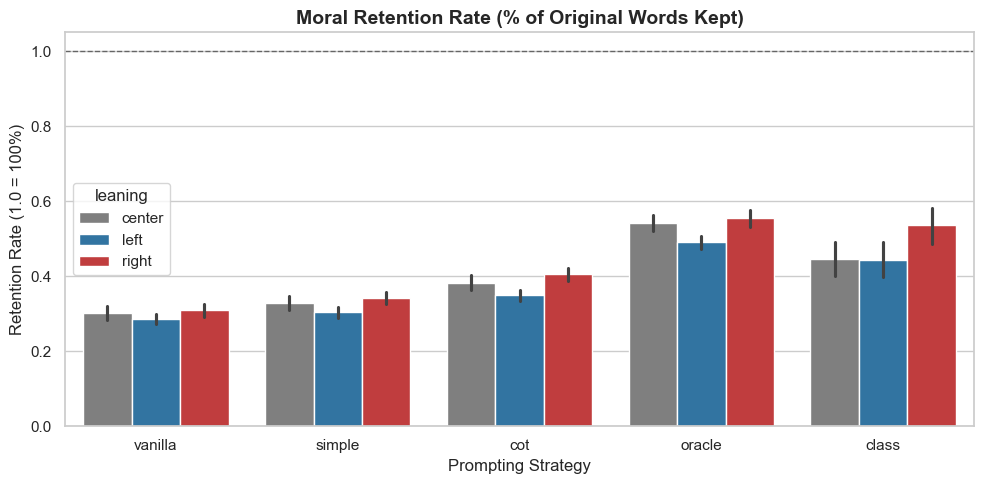

In [69]:
if 'wide_df' in globals():
    # Filter for moral count metric
    retention_df = wide_df[wide_df['metric'] == 'moral_count'].copy()
    retention_df = retention_df.dropna(subset=['leaning'])
    
    melted_retention = []
    methods_to_plot = [m for m in ['vanilla', 'simple', 'cot', 'oracle', 'class'] if m in retention_df.columns]
    
    for method in methods_to_plot:
        temp = retention_df[['article', 'leaning', 'original', method]].copy()
        # Avoid division by zero
        temp['retention_rate'] = temp[method] / temp['original'].replace(0, 1)
        temp['prompting_method'] = method
        melted_retention.append(temp)
        
    if melted_retention:
        # The reset_index is required here to fix the ValueError from duplicate indices!
        final_retention = pd.concat(melted_retention).reset_index(drop=True)
        
        plt.figure(figsize=(10, 5))
        sns.barplot(
            data=final_retention, 
            x='prompting_method', 
            y='retention_rate', 
            hue='leaning', 
            palette=ideology_colors
        )
        plt.title('Moral Retention Rate (% of Original Words Kept)', fontsize=14, fontweight='bold')
        plt.xlabel('Prompting Strategy', fontsize=12)
        plt.ylabel('Retention Rate (1.0 = 100%)', fontsize=12)
        plt.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5) # 100% reference line
        plt.tight_layout()
        plt.savefig('fig2_moral_retention_rate.png', dpi=300)
        plt.show()

### 8.3. Distribution of Moral Divergence (Violin Plot)
This shows how much the moral tone shifted overall (Jensen-Shannon Divergence).

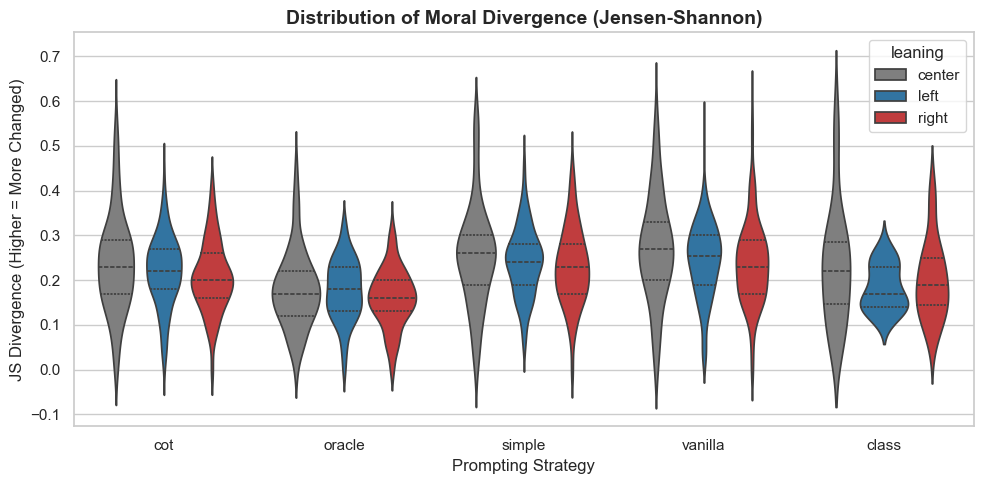

In [70]:
if 'moral_div' in df_summaries.columns:
    plt.figure(figsize=(10, 5))
    sns.violinplot(
        data=df_summaries, 
        x='prompting_method', 
        y='moral_div', 
        hue='leaning', 
        palette=ideology_colors,
        split=False,
        inner="quartile"
    )
    plt.title('Distribution of Moral Divergence (Jensen-Shannon)', fontsize=14, fontweight='bold')
    plt.xlabel('Prompting Strategy', fontsize=12)
    plt.ylabel('JS Divergence (Higher = More Changed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig3_moral_divergence_violin.png', dpi=300)
    plt.show()

### 6.5. Ideology Differences Significance (Mann-Whitney U)
This figure graphs the pairwise Mann-Whitney U test results from earlier in the notebook. It proves whether the differences in moral count between Left, Center, and Right articles are mathematically significant across the board. We plot the **-log10(p-value)** so taller bars indicate stronger statistical proof of bias. The red line marks the `p=0.05` significance threshold.

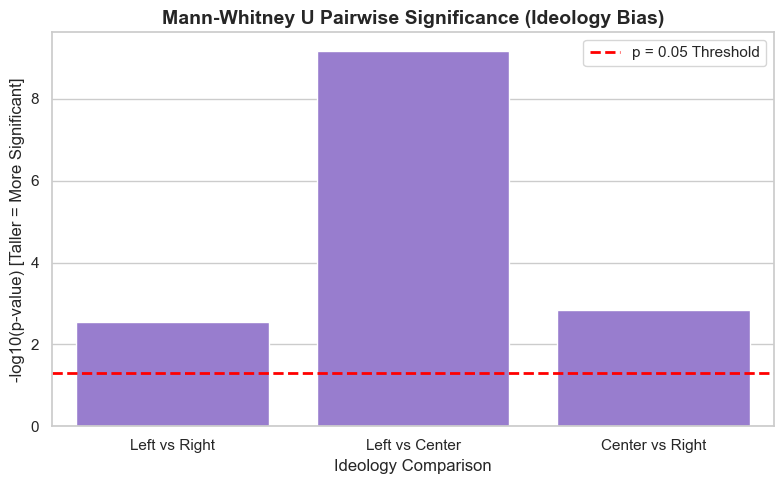

In [71]:
if 'moral_count' in df_summaries.columns:
    left = df_summaries[df_summaries['leaning'] == 'left']['moral_count'].dropna()
    center = df_summaries[df_summaries['leaning'] == 'center']['moral_count'].dropna()
    right = df_summaries[df_summaries['leaning'] == 'right']['moral_count'].dropna()
    
    # Calculate pairwise MWU p-values
    pairs = [
        ('Left vs Right', left, right),
        ('Left vs Center', left, center),
        ('Center vs Right', center, right)
    ]
    
    p_values = []
    labels = []
    
    for label, data1, data2 in pairs:
        if len(data1) > 0 and len(data2) > 0:
            stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            p_values.append(p_val)
            labels.append(label)
            
    if p_values:
        log_p_values = -np.log10(np.array(p_values) + 1e-300)
        
        plt.figure(figsize=(8, 5))
        # Use a neutral color for these bars so they don't clash with the ideology colors
        sns.barplot(x=labels, y=log_p_values, color='#9370db') 
        
        threshold = -np.log10(0.05)
        plt.axhline(threshold, color='red', linestyle='--', linewidth=2, label='p = 0.05 Threshold')
        
        plt.title('Mann-Whitney U Pairwise Significance (Ideology Bias)', fontsize=14, fontweight='bold')
        plt.ylabel('-log10(p-value) [Taller = More Significant]', fontsize=12)
        plt.xlabel('Ideology Comparison', fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.savefig('fig5_ideology_significance.png', dpi=300)
        plt.show()
    else:
        print("Not enough data to compute pairwise significance.")
